# Action Gap — Delay and Phase-Transition Method Comparison

Reads the canonical DTL logs from `logs/sim2real_actions/cityflow_{agent}/{network}/…/logger/`.
Action DTLs have 11 tab-separated columns (the shared 9 plus `violation_rate`, `forceoff_rate`).

## Part 1 — execution delay

Run dirs `action_delay_optimized_s0_*_s0`. **Settings = real execution delay** (sim-steps):
`setting1`=20, `setting2`=30, `setting3`=40, `setting4`=60. Method configs freeze the *assumed* delay
at 20, so settings 2–4 measure the sim↔real delay mismatch of a model shipped for a 20-step countdown.

- `direct_transfer` — pretrained tsc policy zero-shot under the real delay; one run dir per setting,
  single `REAL_TEST` row.
- `naive` / `oblivious_q` / `delayed_q` / `prlight` — train once per network, then replay-evaluate every
  checkpoint under all four real delays (`--replay_curve`): one run dir with per-setting DTLs, the
  setting parsed from the `exp_name` prefix. Top-`TOP_REWARD_K` `REAL_TEST` rows by reward, averaged.

## Part 2 — NEMA phase transition (further below)

Run dirs `action_pt_s0_{method}_{setting}_s0` on the four NEMA networks
(`tempe_1x1`, `bullhead_1`, `tempe_16`, `bullhead_3`), settings `cyclic` / `flexible` /
`barrier_leading_fixed` / `barrier_lagging_fixed` / `barrier_leading_lagging_fixed`. The method
roster crosses adaptation × deployment shielding (2026-07-21 runs added the missing cells):
`direct_transfer`, `dr` / `dr_noshield`, `gat` / `gat_shield`, `ugat` / `ugat_shield`.
`gat`-family runs log only `REAL_TRAIN` rollouts (top-K by reward); `dr`-family has a `REAL_TEST`
replay curve; `direct_transfer` a single zero-shot row.

**Shielding status** (`real_phase_transition_mode` per `configs/sim2real_actions/*.yml`):
`direct_transfer` / `dr_noshield` / `gat` / `ugat` deploy UNSHIELDED (`enforce` — illegal requests
silently dropped to hold); `dr` / `gat_shield` / `ugat_shield` deploy with `shield`, so their
0 violations are by construction. Each shielded/unshielded pair shares its training recipe, so the
pair difference isolates what the deployment shield buys on top of that adaptation.

The PT tables report mean TOTAL `violations` / `force_offs` per episode (absolute counts from the
BRF logs; a force-off is never double-counted as a violation). Totals are per-network quantities —
decision counts differ across networks — the per-decision rates remain in the DTLs.

**Gap** (both parts) = selected real metric − pretrained-tsc CityFlow baseline
(`logs/engine_baselines/{agent}/{network}/cityflow_direct_transfer`, `FINAL_TEST` row) — the
project-wide reference, replacing the old naive-`SIM_TRAIN`-ep0 sim baseline. ATT is the headline;
the CSVs also carry queue/delay/throughput gaps (reward excluded; for throughput negative is worse).

**Note.** Parsing, selection and the CSV export live in `scripts/gap_tables.py` (shared with `make_figures.ipynb`); this notebook is the exploratory companion — availability, pivot tables, bar charts and per-checkpoint traces.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# All parsing + selection logic lives in scripts/gap_tables.py (shared with
# make_figures.ipynb). Part 1 (execution delay) builds tables/action_table.csv;
# the PT cell below builds tables/action_pt_table.csv.
from scripts.gap_tables import (ACTION_DELAY, ACTION_PT,
                                ACTION_SETTING_DELAY as SETTING_DELAY, AGENTS)

results_df = ACTION_DELAY.build(verbose=True)

NETWORK_ORDER = ACTION_DELAY.networks
SETTING_ORDER = ACTION_DELAY.settings
METHOD_ORDER = ACTION_DELAY.methods
SINGLE_SHOT_METHODS = ACTION_DELAY.single_shot
candidate_dtls, real_rows, read_dtl = (ACTION_DELAY.candidate_dtls,
                                       ACTION_DELAY.real_rows, ACTION_DELAY.read_dtl)

# fixed method -> color, consistent across every figure. Tol-bright derived, re-stepped
# 2026-07-22 to pass the palette validator on white (lightness band 0.43-0.77, chroma >= 0.10,
# adjacent-pair CVD dE >= 8): #4477AA -> #3F76BE, #CCBB44 -> #B5A32E, #66CCEE -> #4BAED4.
# PT shielded/unshielded pairs share a hue (shielded = darker step); delayed_q reuses the
# gat slot so direct_transfer keeps its color everywhere.
METHOD_COLORS = {
    'direct_transfer': '#3F76BE',
    'naive': '#EE6677',
    'oblivious_q': '#228833',
    'delayed_q': '#B5A32E',
    'prlight': '#AA3377',
    'dr': '#B23A4E',
    'dr_noshield': '#EE6677',
    'gat': '#B5A32E',
    'gat_shield': '#7A6C15',
    'ugat': '#4BAED4',
    'ugat_shield': '#0E70A0',
}


action delay: 400 runs loaded, 0 missing
wrote 400 rows to tables/action_table.csv


## Delay — Method Availability

In [2]:
availability = (
    results_df.pivot_table(index=['agent', 'network'], columns='method',
                           values='travel_time', aggfunc='count', observed=False)
    .reindex(columns=METHOD_ORDER)
    .fillna(0).astype(int)
)
availability  # number of settings with a usable run, per method

method                  direct_transfer  naive  oblivious_q  delayed_q  \
agent      network                                                       
dqn        tempe_1x1                  4      4            4          4   
           bullhead_1                 4      4            4          4   
           cologne1                   4      4            4          4   
           ingolstadt1                4      4            4          4   
           hz1x1                      4      4            4          4   
           tempe_16                   4      4            4          4   
           bullhead_3                 4      4            4          4   
           cologne3                   4      4            4          4   
           ingolstadt7                4      4            4          4   
           hz4x4                      4      4            4          4   
presslight tempe_1x1                  4      4            4          4   
           bullhead_1                 4      4            4          4   
           cologne1                   4      4            4          4   
           ingolstadt1                4      4            4          4   
           hz1x1                      4      4            4          4   
           tempe_16                   4      4            4          4   
           bullhead_3                 4      4            4          4   
           cologne3                   4      4            4          4   
           ingolstadt7                4      4            4          4   
           hz4x4                      4      4            4          4   

method                  prlight  
agent      network               
dqn        tempe_1x1          4  
           bullhead_1         4  
           cologne1           4  
           ingolstadt1        4  
           hz1x1              4  
           tempe_16           4  
           bullhead_3         4  
           cologne3           4  
           ingolstadt7        4  
           hz4x4              4  
presslight tempe_1x1          4  
           bullhead_1         4  
           cologne1           4  
           ingolstadt1        4  
           hz1x1              4  
           tempe_16           4  
           bullhead_3         4  
           cologne3           4  
           ingolstadt7        4  
           hz4x4              4

## Delay — Real Travel-Time Tables (selected real rows)

In [3]:
att_tables = {
    agent: (
        results_df[results_df['agent'] == agent]
        .pivot_table(index=['network', 'setting'], columns='method', values='travel_time', observed=False)
        .reindex(columns=METHOD_ORDER)
        .round(1)
    )
    for agent in AGENTS
}
att_tables['dqn']

method                direct_transfer   naive  oblivious_q  delayed_q  prlight
network     setting                                                           
tempe_1x1   setting1            516.3   471.0        508.9      167.2    174.8
            setting2            609.1   597.0        582.8      186.5    188.7
            setting3            708.1   697.4        651.8      211.3    206.2
            setting4            749.6   481.3        511.0      251.6    245.4
bullhead_1  setting1           2170.6   312.4        238.2      138.6    143.2
            setting2           1514.5   426.3        253.2      155.9    169.6
            setting3           1370.1   318.6        276.2      171.8    175.7
            setting4            845.4   275.3        279.3      173.2    178.5
cologne1    setting1            187.6   181.6        174.2       57.8     59.6
            setting2            240.1   231.0        262.4       70.4    100.2
            setting3            283.0   203.8        287.4       84.6    110.0
            setting4            287.4   280.2        277.8       87.2     97.9
ingolstadt1 setting1            138.4    70.0         97.4       46.1     46.4
            setting2            178.3   117.4        119.3       53.9     66.6
            setting3            161.4   114.9        139.9       62.2     71.5
            setting4            195.7   190.3        185.2       81.3     93.0
hz1x1       setting1            356.4   345.0        333.5      326.9    325.8
            setting2            569.5   429.7        331.1      313.8    327.7
            setting3            378.0   457.9        361.6      328.3    354.8
            setting4            418.2   408.1        390.1      365.3    387.8
tempe_16    setting1            553.9   388.8        389.7       96.0     94.7
            setting2            657.0   442.2        502.0      108.3    107.0
            setting3            743.3   619.7        596.1      121.7    116.7
            setting4            526.5   478.4        479.6      140.1    136.7
bullhead_3  setting1            847.3   645.0        658.9      196.9    187.3
            setting2           1354.7   593.4        709.4      237.2    221.7
            setting3           1397.5   953.5        904.3      216.3    217.8
            setting4           1283.6  1116.8       1121.5      229.7    259.1
cologne3    setting1            345.5   354.1        348.1       85.1     86.5
            setting2            530.3   433.9        344.2       88.0     97.4
            setting3            533.8   375.5        438.5       90.6     95.1
            setting4            369.7   420.3        402.4      133.4    108.4
ingolstadt7 setting1            498.1   420.4        502.4      135.5    141.2
            setting2            482.8   465.2        584.1      156.2    166.6
            setting3            824.3   568.0        563.4      159.8    202.8
            setting4            954.8   899.0        805.6      204.1    246.0
hz4x4       setting1           1070.5   885.9        872.9      621.5    541.5
            setting2           1121.5   940.6        940.1      695.0    614.7
            setting3           1144.6  1045.0       1019.7      734.4    654.2
            setting4           1201.4  1196.1       1130.6      862.9    798.4

In [4]:
att_tables['presslight']

method                direct_transfer   naive  oblivious_q  delayed_q  prlight
network     setting                                                           
tempe_1x1   setting1            665.4   470.5        478.8      169.3    188.8
            setting2            868.6   582.0        527.3      182.7    201.4
            setting3            820.0   542.3        616.1      203.6    225.3
            setting4            871.8   768.8        570.3      255.0    261.3
bullhead_1  setting1            426.2   407.9        415.9      156.6    165.6
            setting2            862.0   417.4        493.5      167.0    168.9
            setting3            815.2   503.9        574.7      165.9    179.0
            setting4            352.1   563.0        444.5      173.4    192.6
cologne1    setting1            196.5   173.7        184.3       64.6     59.2
            setting2            160.2   227.4        238.4       82.1     78.4
            setting3            176.2   263.9        168.1       90.6     92.2
            setting4            174.4   239.7        148.1       90.8     87.9
ingolstadt1 setting1            130.6   102.0         80.4       47.3     58.5
            setting2            217.0   110.0        153.1       54.6     90.6
            setting3            204.2   127.9        150.8      103.3    110.9
            setting4            199.1   142.3        181.4       93.0    106.5
hz1x1       setting1            483.5   447.4        395.1      432.8    398.6
            setting2            480.8   417.1        403.5      438.3    566.6
            setting3            550.7   411.9        384.8      474.5    509.0
            setting4            533.5   395.9        394.2      424.0    532.0
tempe_16    setting1            476.4   412.5        407.8      116.6    105.7
            setting2            633.8   522.0        562.2      130.8    125.9
            setting3            568.6   571.2        578.1      154.4    149.1
            setting4            505.4   509.7        554.7      155.0    155.6
bullhead_3  setting1           1231.2   775.3        884.5      259.3    214.8
            setting2           1065.2  1177.1       1139.1      412.6    341.1
            setting3           1058.5  1242.1        866.1      380.0    348.0
            setting4           1340.8   818.1        513.2      352.0    325.7
cologne3    setting1            333.6   410.1        284.2      125.4    154.0
            setting2            588.1   523.9        488.9       90.9     95.4
            setting3            569.1   557.9        501.7       98.6    108.4
            setting4            374.2   424.6        448.8      115.5    115.5
ingolstadt7 setting1            499.1   474.5        711.6      314.0    190.1
            setting2            888.7   694.3        734.7      246.8    202.9
            setting3            864.1   725.4        600.7      428.0    237.7
            setting4            879.5  1017.7        886.5      348.6    409.0
hz4x4       setting1            904.8   889.8        863.7      807.7    745.6
            setting2           1181.8  1015.0        998.1      889.0    857.2
            setting3           1197.8   984.1       1024.1      983.6    930.2
            setting4           1377.4  1165.7       1218.9     1043.8   1073.8

## Delay — Gap vs CityFlow Baseline — `gap = real ATT − pretrained cityflow ATT`

In [5]:
gap_tables = {}
for agent in AGENTS:
    sub = results_df[results_df['agent'] == agent]
    table = (
        sub.pivot_table(index=['network', 'setting'], columns='method', values='gap_vs_cityflow', observed=False)
        .reindex(columns=METHOD_ORDER)
    )
    table.insert(0, 'cityflow_att', sub.groupby(['network', 'setting'], observed=False)['cityflow_att'].first())
    gap_tables[agent] = table.round(1)
gap_tables['dqn']

method                cityflow_att  direct_transfer  naive  oblivious_q  \
network     setting                                                       
tempe_1x1   setting1         143.0            373.3  328.0        365.9   
            setting2         143.0            466.1  454.0        439.8   
            setting3         143.0            565.1  554.4        508.8   
            setting4         143.0            606.6  338.3        368.0   
bullhead_1  setting1         117.9           2052.7  194.5        120.3   
            setting2         117.9           1396.6  308.4        135.3   
            setting3         117.9           1252.2  200.7        158.3   
            setting4         117.9            727.5  157.4        161.4   
cologne1    setting1          42.1            145.5  139.5        132.1   
            setting2          42.1            198.0  188.9        220.3   
            setting3          42.1            240.9  161.7        245.3   
            setting4          42.1            245.3  238.1        235.7   
ingolstadt1 setting1          30.2            108.2   39.8         67.2   
            setting2          30.2            148.1   87.2         89.1   
            setting3          30.2            131.2   84.7        109.7   
            setting4          30.2            165.5  160.1        155.0   
hz1x1       setting1         113.8            242.6  231.2        219.7   
            setting2         113.8            455.7  315.9        217.3   
            setting3         113.8            264.2  344.1        247.8   
            setting4         113.8            304.4  294.3        276.3   
tempe_16    setting1          76.1            477.8  312.7        313.6   
            setting2          76.1            580.9  366.1        425.9   
            setting3          76.1            667.2  543.6        520.0   
            setting4          76.1            450.4  402.3        403.5   
bullhead_3  setting1         125.3            722.0  519.7        533.6   
            setting2         125.3           1229.4  468.1        584.1   
            setting3         125.3           1272.2  828.2        779.0   
            setting4         125.3           1158.3  991.5        996.2   
cologne3    setting1          67.4            278.1  286.7        280.7   
            setting2          67.4            462.9  366.5        276.8   
            setting3          67.4            466.4  308.1        371.1   
            setting4          67.4            302.3  352.9        335.0   
ingolstadt7 setting1          63.7            434.4  356.7        438.7   
            setting2          63.7            419.1  401.5        520.4   
            setting3          63.7            760.6  504.3        499.7   
            setting4          63.7            891.1  835.3        741.9   
hz4x4       setting1         355.1            715.4  530.8        517.8   
            setting2         355.1            766.4  585.5        585.0   
            setting3         355.1            789.5  689.9        664.6   
            setting4         355.1            846.3  841.0        775.5   

method                delayed_q  prlight  
network     setting                       
tempe_1x1   setting1       24.2     31.8  
            setting2       43.5     45.7  
            setting3       68.3     63.2  
            setting4      108.6    102.4  
bullhead_1  setting1       20.7     25.3  
            setting2       38.0     51.7  
            setting3       53.9     57.8  
            setting4       55.3     60.6  
cologne1    setting1       15.7     17.5  
            setting2       28.3     58.1  
            setting3       42.5     67.9  
            setting4       45.1     55.8  
ingolstadt1 setting1       15.9     16.2  
            setting2       23.7     36.4  
            setting3       32.0     41.3  
            setting4       51.1     62.8  
hz1x1       setting1      213.1    212.0  
            setting2      200.0 

In [6]:
gap_tables['presslight']

method                cityflow_att  direct_transfer   naive  oblivious_q  \
network     setting                                                        
tempe_1x1   setting1         143.1            522.3   327.4        335.7   
            setting2         143.1            725.5   438.9        384.2   
            setting3         143.1            676.9   399.2        473.0   
            setting4         143.1            728.7   625.7        427.2   
bullhead_1  setting1         121.0            305.2   286.9        294.9   
            setting2         121.0            741.0   296.4        372.5   
            setting3         121.0            694.2   382.9        453.7   
            setting4         121.0            231.1   442.0        323.5   
cologne1    setting1          44.0            152.5   129.7        140.3   
            setting2          44.0            116.2   183.4        194.4   
            setting3          44.0            132.2   219.9        124.1   
            setting4          44.0            130.4   195.7        104.1   
ingolstadt1 setting1          32.5             98.1    69.5         47.9   
            setting2          32.5            184.5    77.5        120.6   
            setting3          32.5            171.7    95.4        118.3   
            setting4          32.5            166.6   109.8        148.9   
hz1x1       setting1         112.2            371.3   335.2        282.9   
            setting2         112.2            368.6   304.9        291.3   
            setting3         112.2            438.5   299.7        272.6   
            setting4         112.2            421.3   283.7        282.0   
tempe_16    setting1          76.2            400.2   336.3        331.6   
            setting2          76.2            557.6   445.8        486.0   
            setting3          76.2            492.4   495.0        501.9   
            setting4          76.2            429.2   433.5        478.5   
bullhead_3  setting1         128.1           1103.1   647.2        756.4   
            setting2         128.1            937.1  1049.0       1011.0   
            setting3         128.1            930.4  1114.0        738.0   
            setting4         128.1           1212.7   690.0        385.1   
cologne3    setting1          63.9            269.7   346.2        220.3   
            setting2          63.9            524.2   460.0        425.0   
            setting3          63.9            505.2   494.0        437.8   
            setting4          63.9            310.3   360.7        384.9   
ingolstadt7 setting1          63.9            435.2   410.6        647.7   
            setting2          63.9            824.8   630.4        670.8   
            setting3          63.9            800.2   661.5        536.8   
            setting4          63.9            815.6   953.8        822.6   
hz4x4       setting1         349.2            555.6   540.6        514.5   
            setting2         349.2            832.6   665.8        648.9   
            setting3         349.2            848.6   634.9        674.9   
            setting4         349.2           1028.2   816.5        869.7   

method                delayed_q  prlight  
network     setting                       
tempe_1x1   setting1       26.2     45.7  
            setting2       39.6     58.3  
            setting3       60.5     82.2  
            setting4      111.9    118.2  
bullhead_1  setting1       35.6     44.6  
            setting2       46.0     47.9  
            setting3       44.9     58.0  
            setting4       52.4     71.6  
cologne1    setting1       20.6     15.2  
            setting2       38.1     34.4  
            setting3       46.6     48.2  
            setting4       46.8     43.9  
ingolstadt1 setting1       14.8     26.0  
            setting2       22.1     58.1  
            setting3       70.8     78.4  
            setting4       60.5     74.0  
hz1x1       setting1      320.6  

## Delay — Gap Bar Chart

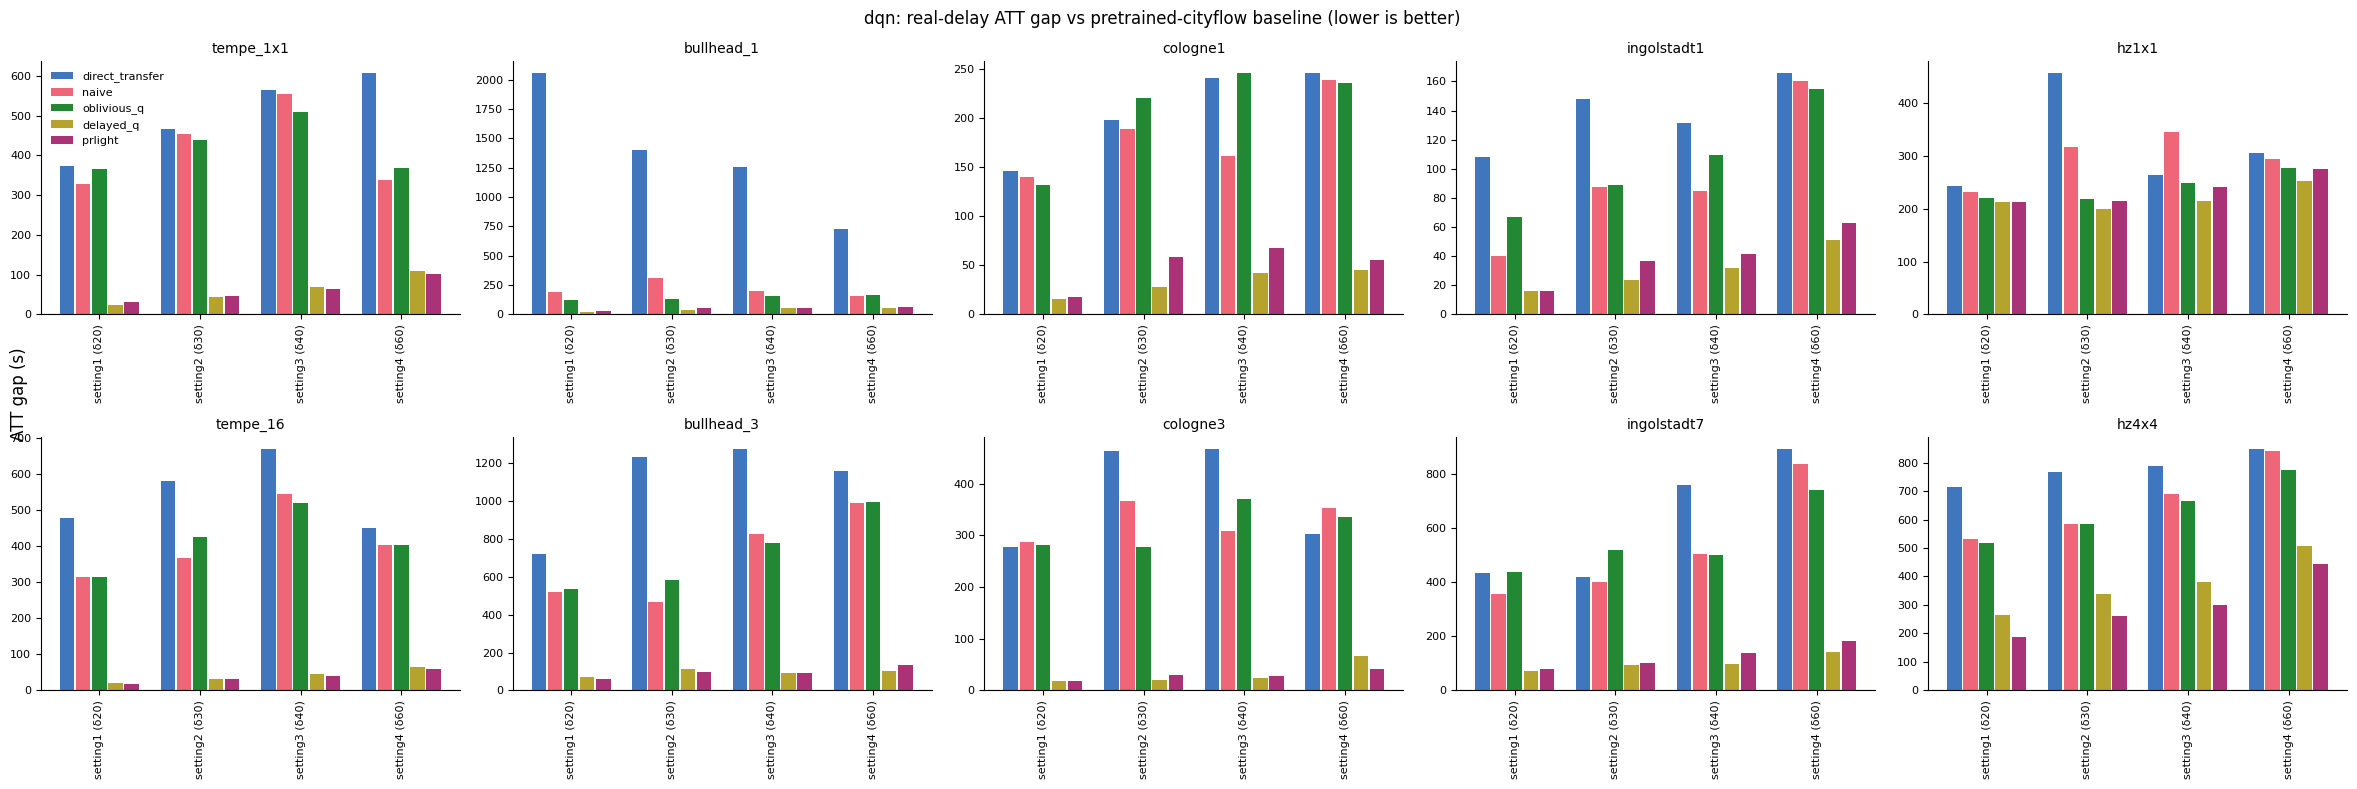

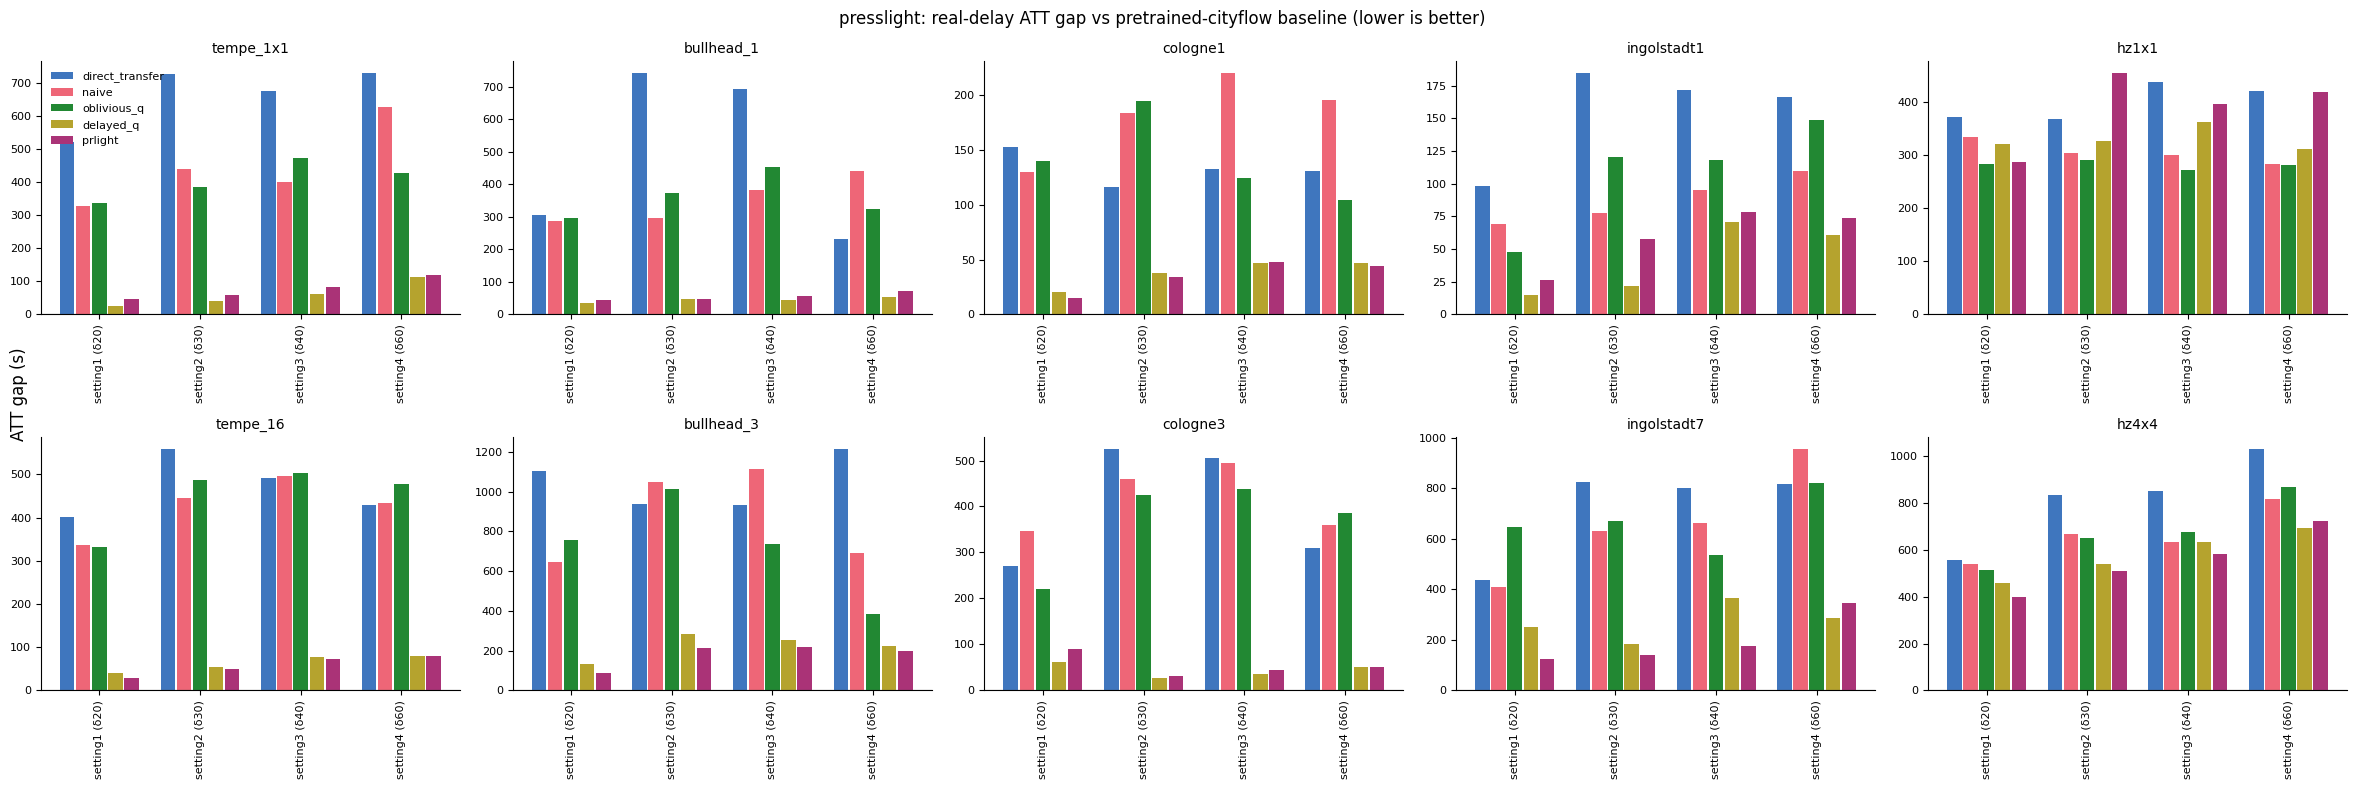

In [7]:
import matplotlib.pyplot as plt


def plot_gap_bars(agent, df, networks, methods, settings, xticklabels, figsize=(24, 8)):
    sub = df[df['agent'] == agent]
    fig, axes = plt.subplots(2, 5, figsize=figsize, squeeze=False)
    x = np.arange(len(settings))
    width = 0.8 / len(methods)
    for ax, network in zip(axes.flat, networks):
        net_df = sub[sub['network'] == network]
        for i, method in enumerate(methods):
            vals = [
                net_df[(net_df['setting'] == s) & (net_df['method'] == method)]['gap_vs_cityflow'].mean()
                for s in settings
            ]
            ax.bar(x + (i - (len(methods) - 1) / 2) * width, vals, width * 0.9,
                   color=METHOD_COLORS[method], label=method)
        ax.axhline(0, color='0.4', linewidth=0.8)
        ax.set_title(str(network), fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(xticklabels, fontsize=7, rotation=90)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
    for ax in axes.flat[len(networks):]:
        ax.set_visible(False)
    axes.flat[0].legend(loc='upper left', fontsize=8, frameon=False)
    fig.suptitle(f'{agent}: real-delay ATT gap vs pretrained-cityflow baseline (lower is better)')
    fig.supylabel('ATT gap (s)')
    fig.tight_layout()
    plt.show()


for agent in AGENTS:
    plot_gap_bars(agent, results_df, NETWORK_ORDER, METHOD_ORDER, SETTING_ORDER, [f'{s} (\u03b4{SETTING_DELAY[s]})' for s in SETTING_ORDER])

## Delay — Real-Eval Travel-Time Traces

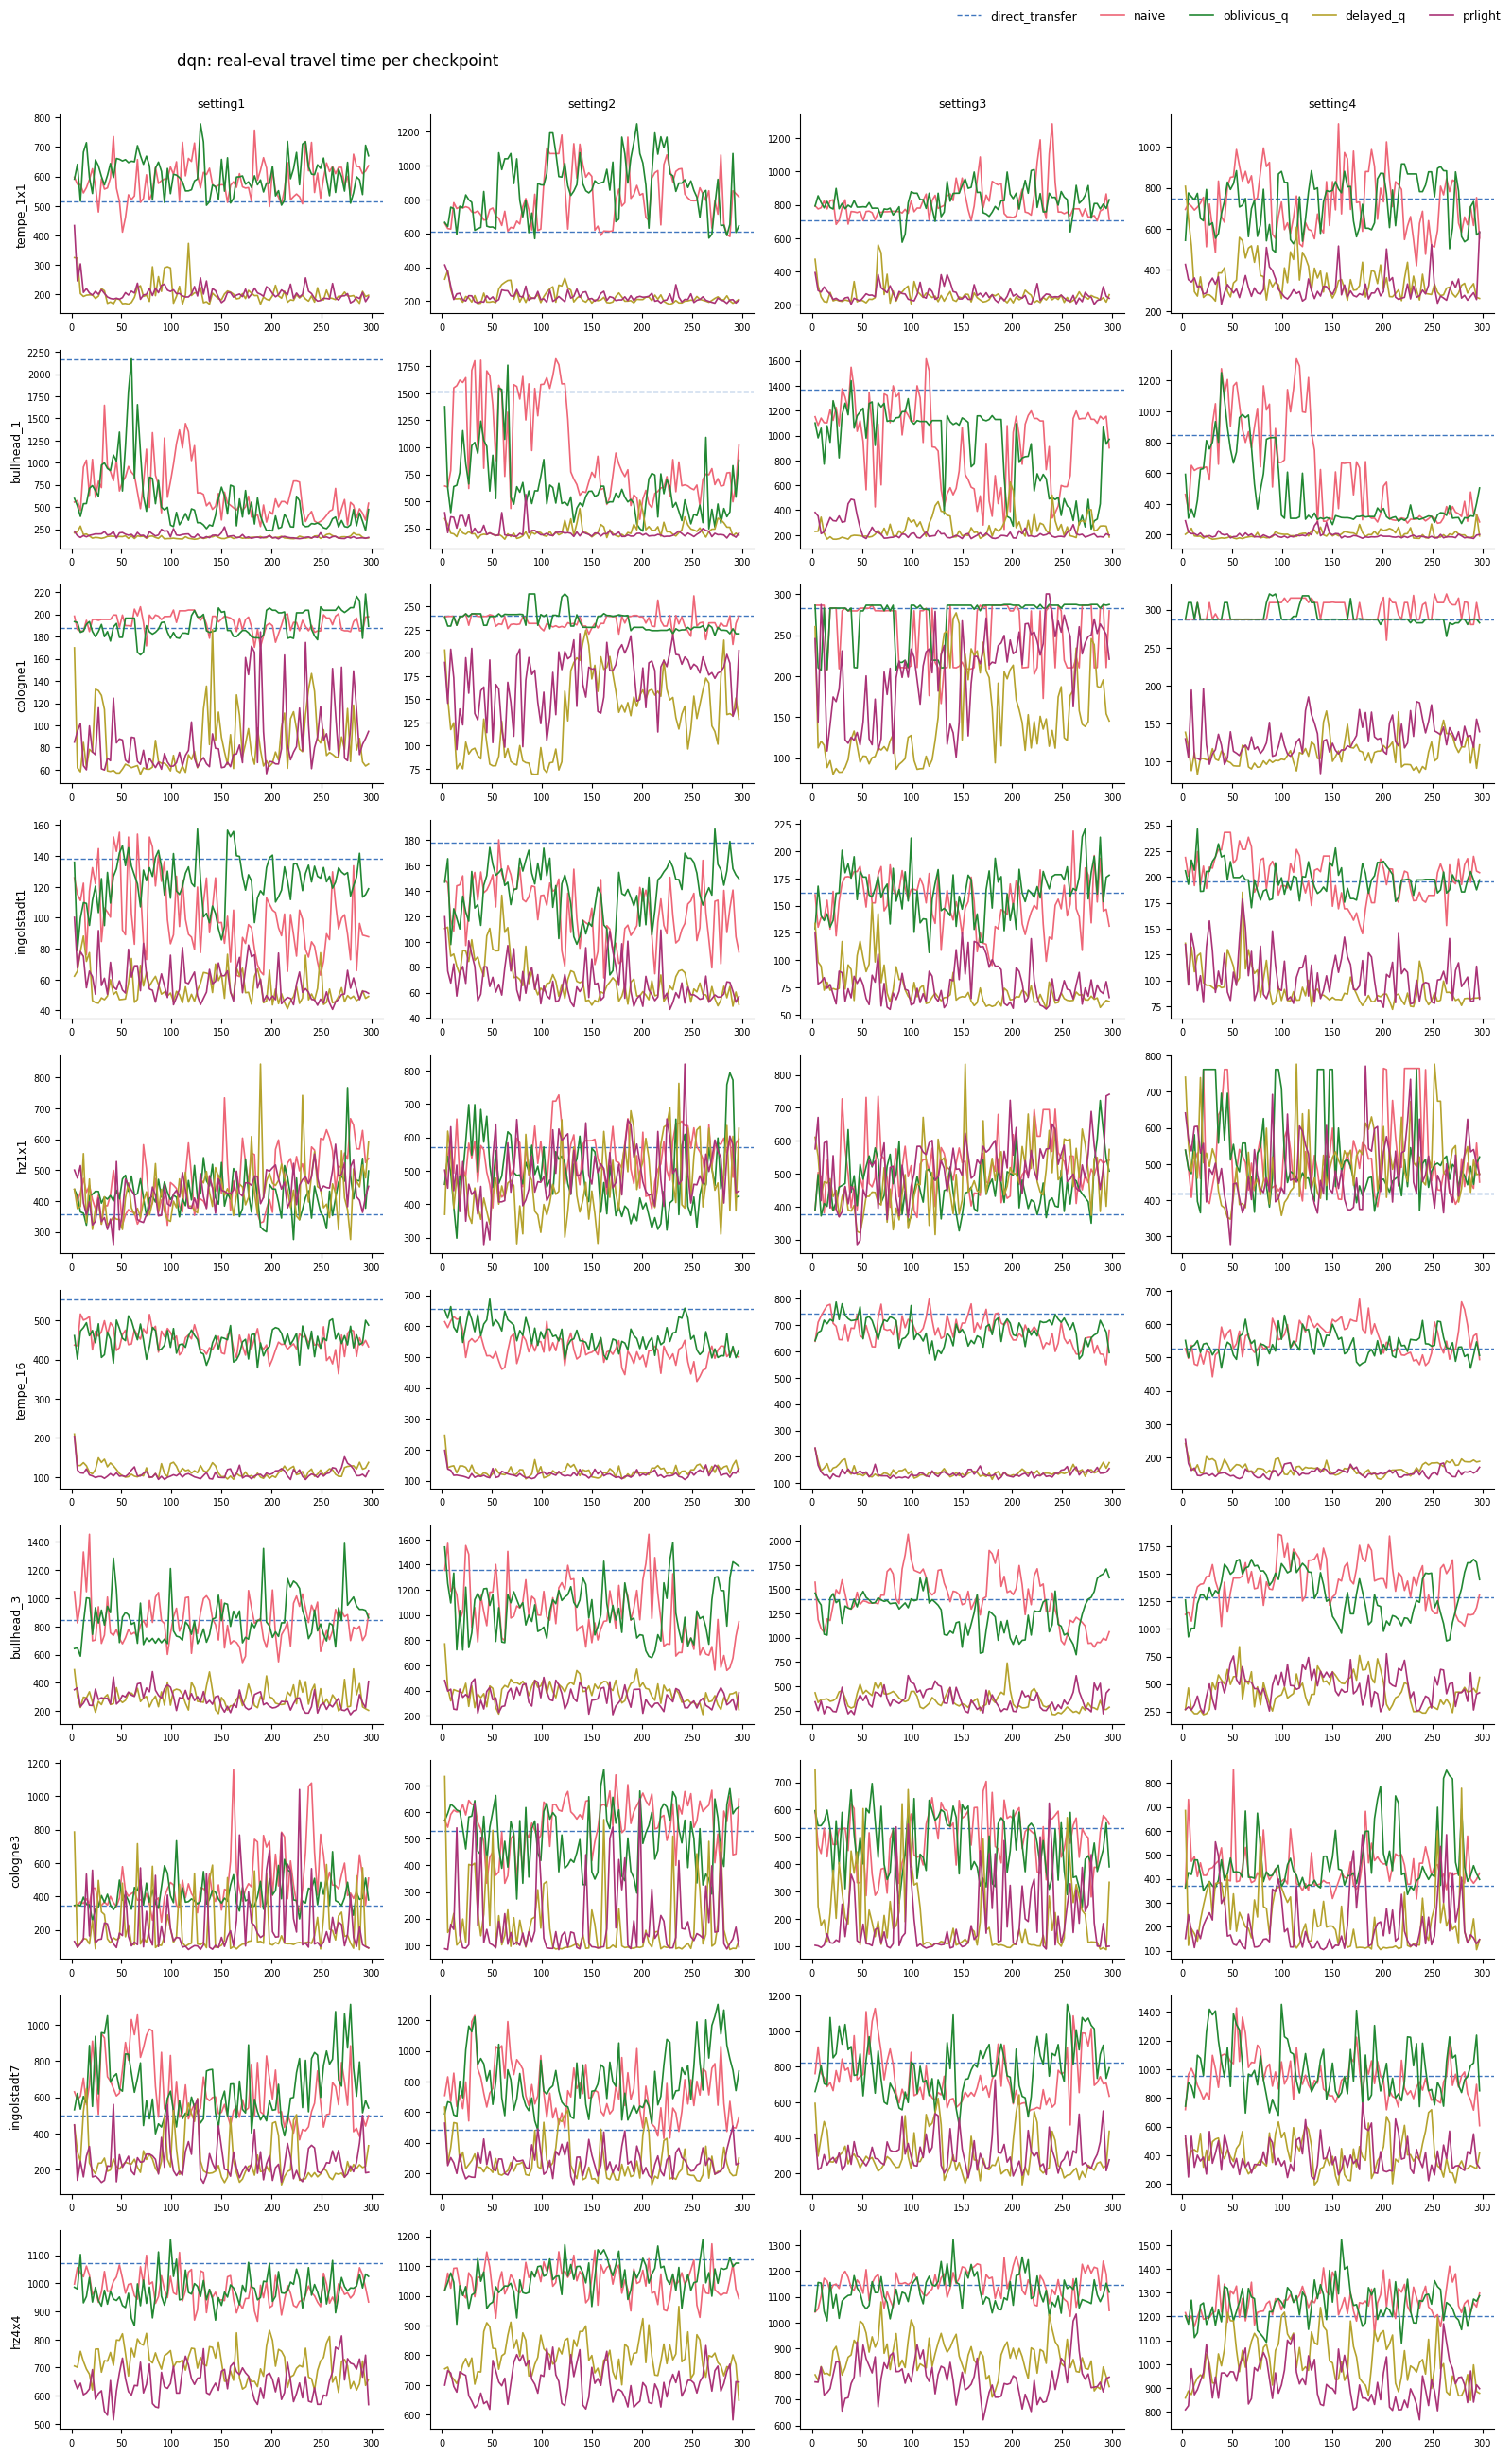

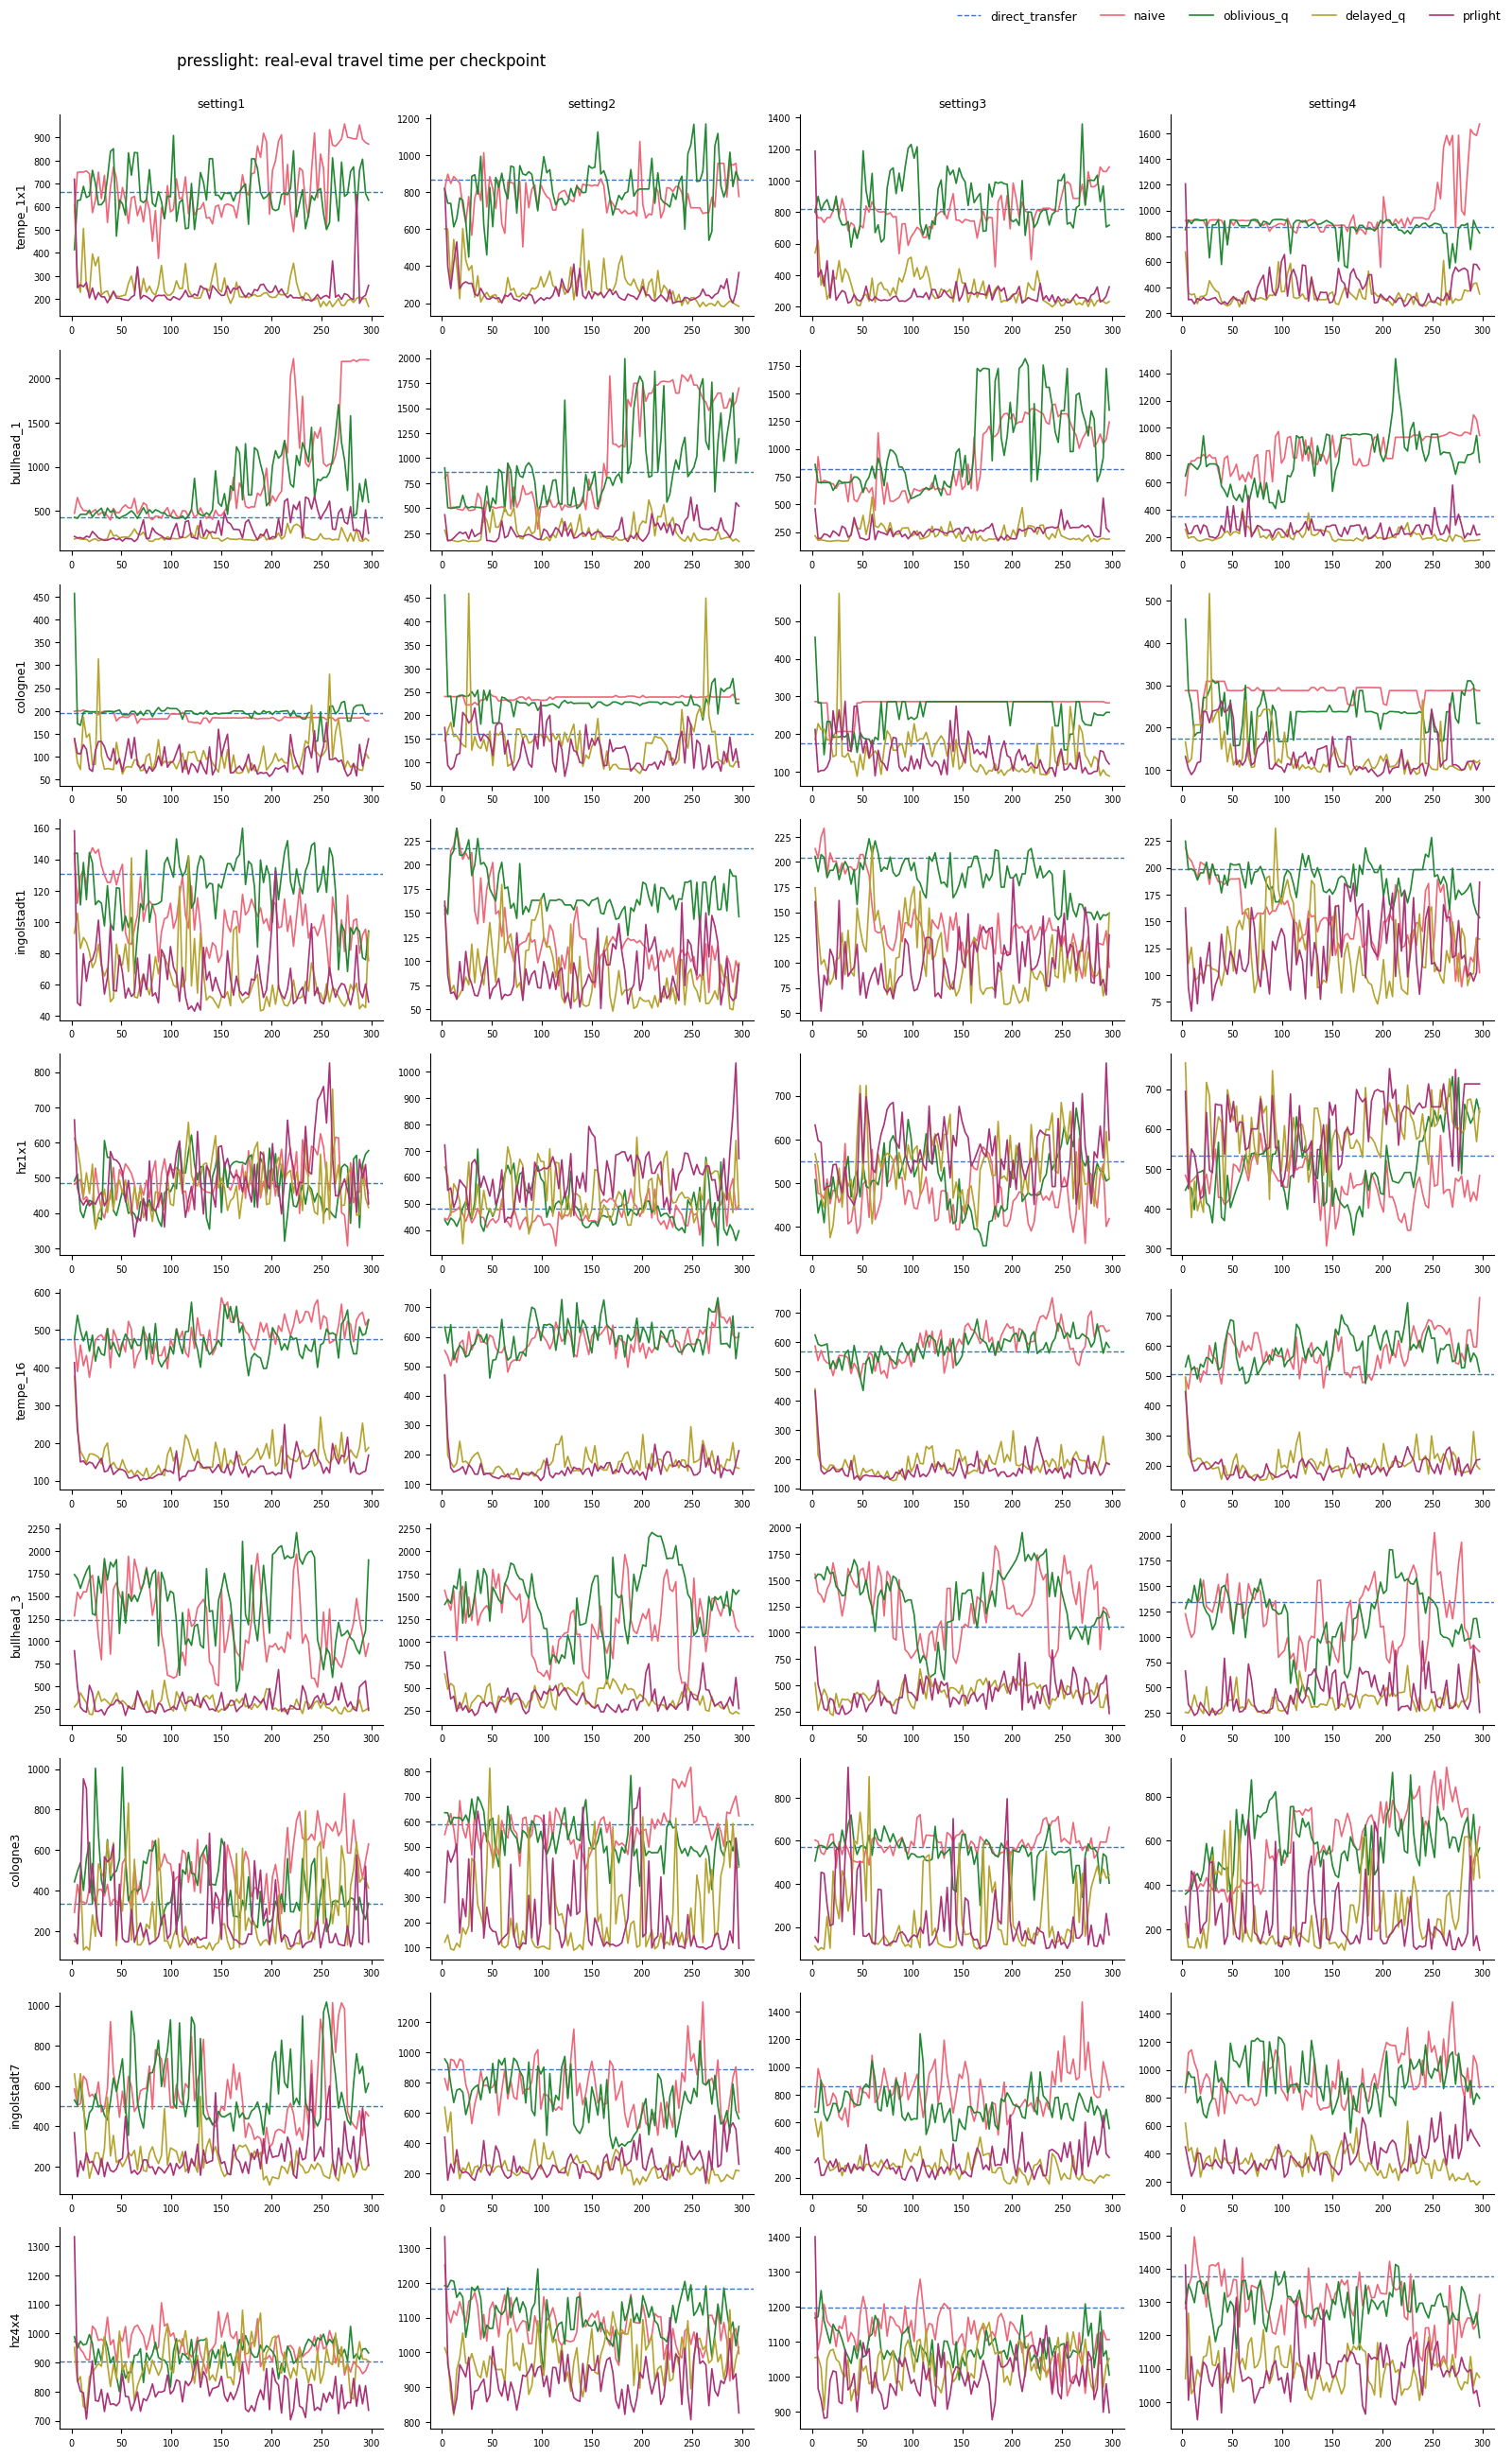

In [8]:
# Real-eval travel-time curves per checkpoint. direct_transfer (single zero-shot row)
# is drawn as a dashed reference line.
TRACE_NETWORKS = NETWORK_ORDER
TRACE_SETTINGS = SETTING_ORDER
TRACE_METHODS = METHOD_ORDER


def real_trace(agent, network, method, setting):
    for log_path in reversed(candidate_dtls(agent, network, method, setting)):
        rows = real_rows(read_dtl(log_path))
        if len(rows) >= 2:
            return rows.sort_values('episode')
    return None


for agent in AGENTS:
    fig, axes = plt.subplots(len(TRACE_NETWORKS), len(TRACE_SETTINGS),
                             figsize=(4 * len(TRACE_SETTINGS), 2.6 * len(TRACE_NETWORKS)), squeeze=False)
    for r, network in enumerate(TRACE_NETWORKS):
        for c, setting in enumerate(TRACE_SETTINGS):
            ax = axes[r, c]
            for method in TRACE_METHODS:
                if method in SINGLE_SHOT_METHODS:
                    dt = results_df[(results_df['agent'] == agent) & (results_df['network'] == network)
                                    & (results_df['setting'] == setting) & (results_df['method'] == method)]
                    if len(dt):
                        ax.axhline(float(dt['travel_time'].iloc[0]), color=METHOD_COLORS[method],
                                   linestyle='--', linewidth=1.0, label=method)
                    continue
                rows = real_trace(agent, network, method, setting)
                if rows is None:
                    continue
                ax.plot(rows['episode'], rows['travel_time'], color=METHOD_COLORS[method],
                        linewidth=1.2, label=method)
            if r == 0:
                ax.set_title(setting, fontsize=9)
            if c == 0:
                ax.set_ylabel(network, fontsize=9)
            ax.tick_params(labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9, frameon=False, ncols=len(TRACE_METHODS))
    fig.suptitle(f'{agent}: real-eval travel time per checkpoint', x=0.12, ha='left')
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()

# Part 2 — NEMA Phase-Transition Gap

Sim uses combined NEMA stages; real is the raw dual-ring NEMA controller. `violation_rate` /
`forceoff_rate` are the shield diagnostics logged by the trainer.

In [9]:
# PT gap: per-setting-trained runs (scripts/gap_tables.py ACTION_PT). The builder
# folds the absolute BRF safety counts (violations / force_offs) of the selected
# episodes into the frame and writes tables/action_pt_table.csv.
pt_results_df = ACTION_PT.build(verbose=True)

PT_NETWORKS = ACTION_PT.networks
PT_SETTING_ORDER = ACTION_PT.settings
PT_METHOD_ORDER = ACTION_PT.methods
pt_candidate_dtls = ACTION_PT.candidate_dtls


action phase-transition: 280 runs loaded, 0 missing
wrote 280 rows to tables/action_pt_table.csv


## PT — Real Travel-Time Tables

In [10]:
pt_att_tables = {
    agent: (
        pt_results_df[pt_results_df['agent'] == agent]
        .pivot_table(index=['network', 'setting'], columns='method', values='travel_time', observed=False)
        .reindex(columns=PT_METHOD_ORDER)
        .round(1)
    )
    for agent in AGENTS
}
pt_att_tables['dqn']

method                                    direct_transfer  dr_noshield     dr  \
network    setting                                                              
tempe_1x1  cyclic                                   198.3        194.6  179.4   
           flexible                                 159.1        159.8  160.2   
           barrier_leading_fixed                    187.0        168.3  170.2   
           barrier_lagging_fixed                   1006.8        164.5  161.4   
           barrier_leading_lagging_fixed           1000.9        181.6  166.2   
bullhead_1 cyclic                                   178.2        174.7  161.2   
           flexible                                 132.5        131.3  130.9   
           barrier_leading_fixed                    157.2        157.3  144.1   
           barrier_lagging_fixed                    156.2        143.4  139.9   
           barrier_leading_lagging_fixed           1877.3        160.1  150.5   
tempe_16   cyclic                                   134.7        125.3  111.0   
           flexible                                  86.6         85.7   85.6   
           barrier_leading_fixed                    259.5        132.7  129.6   
           barrier_lagging_fixed                    146.1         94.4   89.6   
           barrier_leading_lagging_fixed            229.4        148.2  212.4   
bullhead_3 cyclic                                   186.8        184.9  166.2   
           flexible                                 183.0        147.7  147.2   
           barrier_leading_fixed                    686.3        162.3  155.9   
           barrier_lagging_fixed                    347.6        151.7  153.3   
           barrier_leading_lagging_fixed            686.3        163.5  158.5   

method                                      gat  gat_shield   ugat  \
network    setting                                                   
tempe_1x1  cyclic                         194.9       180.5  194.7   
           flexible                       159.0       158.7  159.3   
           barrier_leading_fixed          171.8       170.7  169.2   
           barrier_lagging_fixed          162.2       161.7  167.0   
           barrier_leading_lagging_fixed  199.9       171.5  167.7   
bullhead_1 cyclic                         173.3       165.7  173.8   
           flexible                       128.6       129.7  131.3   
           barrier_leading_fixed          153.3       147.2  151.0   
           barrier_lagging_fixed          159.1       146.1  210.6   
           barrier_leading_lagging_fixed  166.7       158.5  154.5   
tempe_16   cyclic                         125.2       111.6  128.8   
           flexible                        86.6        86.8   85.8   
           barrier_leading_fixed          156.0       225.4  155.4   
           barrier_lagging_fixed           91.1        93.9   90.4   
           barrier_leading_lagging_fixed  228.8       240.5  266.3   
bullhead_3 cyclic                         183.2       166.1  184.2   
           flexible                       147.0       152.2  147.6   
           barrier_leading_fixed          154.9       154.4  198.2   
           barrier_lagging_fixed          163.7       155.7  162.4   
           barrier_leading_lagging_fixed  155.4       155.4  177.5   

method                                    ugat_shield  
network    setting                                     
tempe_1x1  cyclic                               179.1  
           flexible                             159.0  
           barrier_leading_fixed                170.2  
           barrier_lagging_fixed                160.3  
           barrier_leading_lagging_fixed        201.0  
bullhead_1 cyclic                               167.0  
           flexible                             131.1  
           barrier_leading_fixed                144.1  
           barrier_lagging_fixed                143.7  
           barrier_leading_lagging_fixed        158.5  
temp

In [11]:
pt_att_tables['presslight']

method                                    direct_transfer  dr_noshield     dr  \
network    setting                                                              
tempe_1x1  cyclic                                   197.5        195.1  182.1   
           flexible                                 166.2        163.7  163.0   
           barrier_leading_fixed                    291.5        168.1  166.6   
           barrier_lagging_fixed                    175.4        164.7  163.3   
           barrier_leading_lagging_fixed            288.0        172.6  179.4   
bullhead_1 cyclic                                   182.0        174.8  165.0   
           flexible                                 132.7        133.1  132.4   
           barrier_leading_fixed                    160.7        155.8  143.4   
           barrier_lagging_fixed                    148.8        144.1  139.3   
           barrier_leading_lagging_fixed            160.7        156.5  144.6   
tempe_16   cyclic                                   132.4        130.2  117.0   
           flexible                                  91.1         89.9   89.6   
           barrier_leading_fixed                    230.2        217.9  193.2   
           barrier_lagging_fixed                    169.7         96.4   92.5   
           barrier_leading_lagging_fixed            306.8        304.4  231.4   
bullhead_3 cyclic                                   183.9        186.1  167.3   
           flexible                                 274.7        159.8  150.4   
           barrier_leading_fixed                    273.6        167.1  161.8   
           barrier_lagging_fixed                    747.7        169.9  158.1   
           barrier_leading_lagging_fixed            674.9        201.0  197.5   

method                                      gat  gat_shield   ugat  \
network    setting                                                   
tempe_1x1  cyclic                         193.1       180.5  195.2   
           flexible                       159.4       162.0  160.3   
           barrier_leading_fixed          191.2       167.5  175.8   
           barrier_lagging_fixed          163.1       161.7  168.5   
           barrier_leading_lagging_fixed  165.4       165.1  168.2   
bullhead_1 cyclic                         174.9       161.7  174.6   
           flexible                       132.7       131.8  132.7   
           barrier_leading_fixed          155.5       146.1  150.2   
           barrier_lagging_fixed          156.3       148.6  146.3   
           barrier_leading_lagging_fixed  154.7       152.8  158.7   
tempe_16   cyclic                         133.2       120.4  132.3   
           flexible                        91.6        90.4   90.6   
           barrier_leading_fixed          330.1       263.9  232.1   
           barrier_lagging_fixed           97.7        92.5  110.3   
           barrier_leading_lagging_fixed  293.5       339.2  320.6   
bullhead_3 cyclic                         182.0       166.6  183.8   
           flexible                       172.2       150.0  146.9   
           barrier_leading_fixed          174.0       190.3  155.2   
           barrier_lagging_fixed          212.6       159.5  275.7   
           barrier_leading_lagging_fixed  160.1       576.4  180.5   

method                                    ugat_shield  
network    setting                                     
tempe_1x1  cyclic                               181.6  
           flexible                             163.8  
           barrier_leading_fixed                171.1  
           barrier_lagging_fixed                164.1  
           barrier_leading_lagging_fixed        167.1  
bullhead_1 cyclic                               161.6  
           flexible                             132.5  
           barrier_leading_fixed                155.7  
           barrier_lagging_fixed                142.9  
           barrier_leading_lagging_fixed        155.7  
temp

## PT — Gap Bar Chart

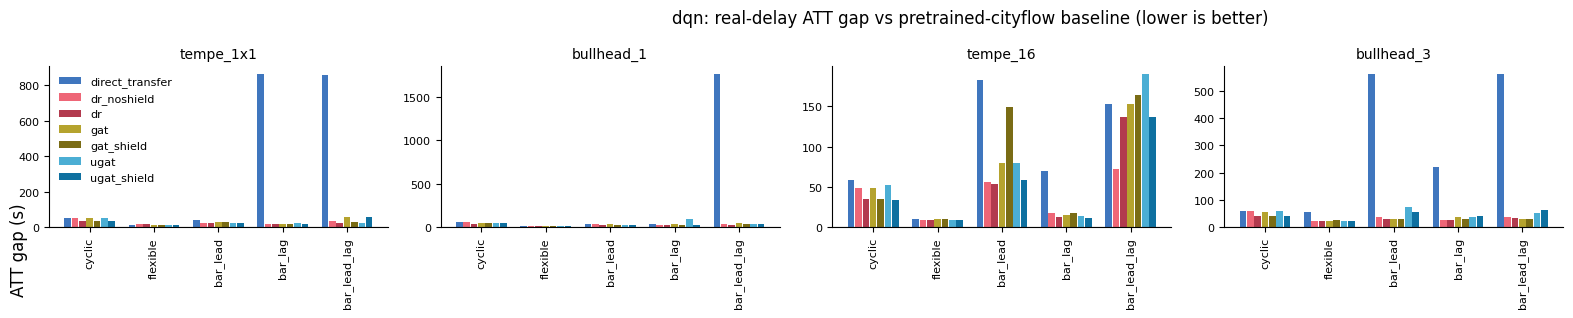

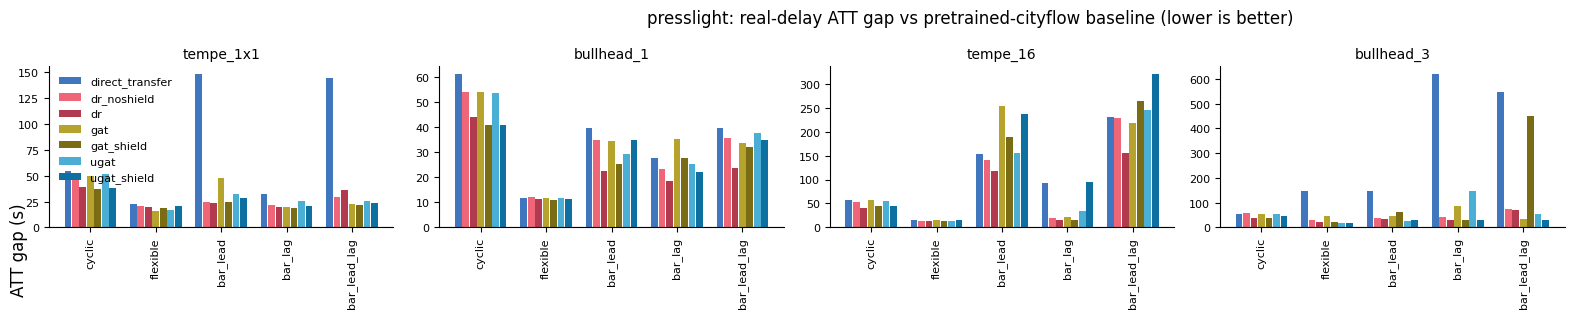

In [12]:
PT_XTICKS = ['cyclic', 'flexible', 'bar_lead', 'bar_lag', 'bar_lead_lag']

for agent in AGENTS:
    plot_gap_bars(agent, pt_results_df, PT_NETWORKS, PT_METHOD_ORDER, PT_SETTING_ORDER, PT_XTICKS,
                  figsize=(20, 5))

## PT — Shield Diagnostics (violation / force-off rates)

In [13]:
# shield diagnostics: mean TOTAL violations / force-offs per episode of the selected
# rows (absolute counts from the BRF; per-decision rates remain in the DTL/results_df).
# NOTE: totals are not comparable across networks (decision counts differ).
pt_safety_tables = {
    agent: (
        pt_results_df[pt_results_df['agent'] == agent]
        .pivot_table(index=['network', 'setting'], columns='method',
                     values=['violations', 'force_offs'], observed=False)
        .round(1)
    )
    for agent in AGENTS
}
pt_safety_tables['dqn']

force_offs                     \
method                                   direct_transfer dr_noshield     dr   
network    setting                                                            
tempe_1x1  cyclic                                  105.0        90.8    9.4   
           flexible                                  1.0         0.0    0.8   
           barrier_leading_fixed                    82.0        67.0   35.2   
           barrier_lagging_fixed                   102.0        31.4    0.6   
           barrier_leading_lagging_fixed           102.0        82.4   41.0   
bullhead_1 cyclic                                   99.0        93.8   31.2   
           flexible                                 22.0         0.6    3.8   
           barrier_leading_fixed                    78.0        78.8   25.2   
           barrier_lagging_fixed                    56.0        45.8    0.4   
           barrier_leading_lagging_fixed           117.0        78.4   11.8   
tempe_16   cyclic                                 1058.0      1043.2  592.4   
           flexible                                346.0       317.6  328.4   
           barrier_leading_fixed                   938.0       898.4  545.0   
           barrier_lagging_fixed                   638.0       519.2  355.0   
           barrier_leading_lagging_fixed           921.0       904.2  595.8   
bullhead_3 cyclic                                  263.0       234.6  132.6   
           flexible                                 75.0       107.8   97.0   
           barrier_leading_fixed                   222.0       175.8  120.2   
           barrier_lagging_fixed                   178.0       128.2  121.6   
           barrier_leading_lagging_fixed           222.0       188.6  112.8   

                                                                     \
method                                       gat gat_shield    ugat   
network    setting                                                    
tempe_1x1  cyclic                           95.0       17.2    95.0   
           flexible                          1.0        0.0     1.0   
           barrier_leading_fixed            70.4       14.2    67.6   
           barrier_lagging_fixed            19.2        1.0    40.0   
           barrier_leading_lagging_fixed    88.6       22.0    66.0   
bullhead_1 cyclic                           94.2       50.8    94.8   
           flexible                         20.4       13.0    16.8   
           barrier_leading_fixed            77.4       30.2    82.6   
           barrier_lagging_fixed            58.8       19.6    67.0   
           barrier_leading_lagging_fixed    74.4       39.4    82.8   
tempe_16   cyclic                         1087.4      547.0  1018.4   
           flexible                        324.4      325.4   310.2   
           barrier_leading_fixed           872.2      602.8   858.2   
           barrier_lagging_fixed           496.0      363.8   458.4   
           barrier_leading_lagging_fixed   918.8      582.8   936.0   
bullhead_3 cyclic                          234.0      152.2   241.2   
           flexible                         48.6       68.2    45.0   
           barrier_leading_fixed           165.8       76.6   152.4   
           barrier_lagging_fixed           140.2       72.8   123.2   
           barrier_leading_lagging_fixed   177.0      100.0   154.4   

                                                          violations  \
method                                   ugat_shield direct_transfer   
network    setting                                                     
tempe_1x1  cyclic                                4.8           226.0   
           flexible                              1.6           179.0   
           barrier_leading_fixed                29.8           221.0   
           barrier_lagging_fixed                 2.0           255.0   
           barrier_leading_lagging_fixed        44.8           256.0   
bullhead_1 cyclic 

In [14]:
pt_safety_tables['presslight']

force_offs                     \
method                                   direct_transfer dr_noshield     dr   
network    setting                                                            
tempe_1x1  cyclic                                  100.0        94.8   34.6   
           flexible                                  7.0         1.4    3.4   
           barrier_leading_fixed                    95.0        66.6   39.4   
           barrier_lagging_fixed                    45.0        33.6   26.4   
           barrier_leading_lagging_fixed            95.0        72.8   50.0   
bullhead_1 cyclic                                   97.0        98.0   56.2   
           flexible                                 27.0        53.0   54.4   
           barrier_leading_fixed                   102.0        64.2   30.2   
           barrier_lagging_fixed                    47.0        66.4   38.6   
           barrier_leading_lagging_fixed           102.0        66.0   45.0   
tempe_16   cyclic                                 1075.0      1082.6  663.4   
           flexible                                326.0       472.8  440.4   
           barrier_leading_fixed                   879.0       996.8  759.2   
           barrier_lagging_fixed                   604.0       644.0  509.8   
           barrier_leading_lagging_fixed           927.0      1056.6  690.8   
bullhead_3 cyclic                                  248.0       258.0  176.6   
           flexible                                145.0       142.8  152.8   
           barrier_leading_fixed                   173.0       231.0  163.2   
           barrier_lagging_fixed                   229.0       184.8  160.8   
           barrier_leading_lagging_fixed           247.0       210.6  159.6   

                                                                     \
method                                       gat gat_shield    ugat   
network    setting                                                    
tempe_1x1  cyclic                           87.4       21.4    95.4   
           flexible                          0.0        0.6     0.8   
           barrier_leading_fixed            83.6       36.4    75.6   
           barrier_lagging_fixed            19.8        0.8    24.4   
           barrier_leading_lagging_fixed    46.6       38.6    66.0   
bullhead_1 cyclic                           90.8       42.0    86.8   
           flexible                         24.2       15.8    15.6   
           barrier_leading_fixed            62.8       30.8    81.8   
           barrier_lagging_fixed            50.4       49.8    48.8   
           barrier_leading_lagging_fixed    59.8       20.8   102.0   
tempe_16   cyclic                         1080.8      706.0  1068.2   
           flexible                        357.8      336.2   321.0   
           barrier_leading_fixed          1003.6      696.2   973.8   
           barrier_lagging_fixed           451.4      377.8   577.6   
           barrier_leading_lagging_fixed   991.2      679.4   948.8   
bullhead_3 cyclic                          249.4      186.2   257.8   
           flexible                        143.0      134.2   156.8   
           barrier_leading_fixed           199.6      165.2   188.0   
           barrier_lagging_fixed           164.4      174.4   171.4   
           barrier_leading_lagging_fixed   168.6      182.8   187.6   

                                                          violations  \
method                                   ugat_shield direct_transfer   
network    setting                                                     
tempe_1x1  cyclic                               28.0           224.0   
           flexible                              0.2           168.0   
           barrier_leading_fixed                49.2           238.0   
           barrier_lagging_fixed                 0.6           198.0   
           barrier_leading_lagging_fixed        61.0           237.0   
bullhead_1 cyclic 

## PT — Real-Eval Travel-Time Traces

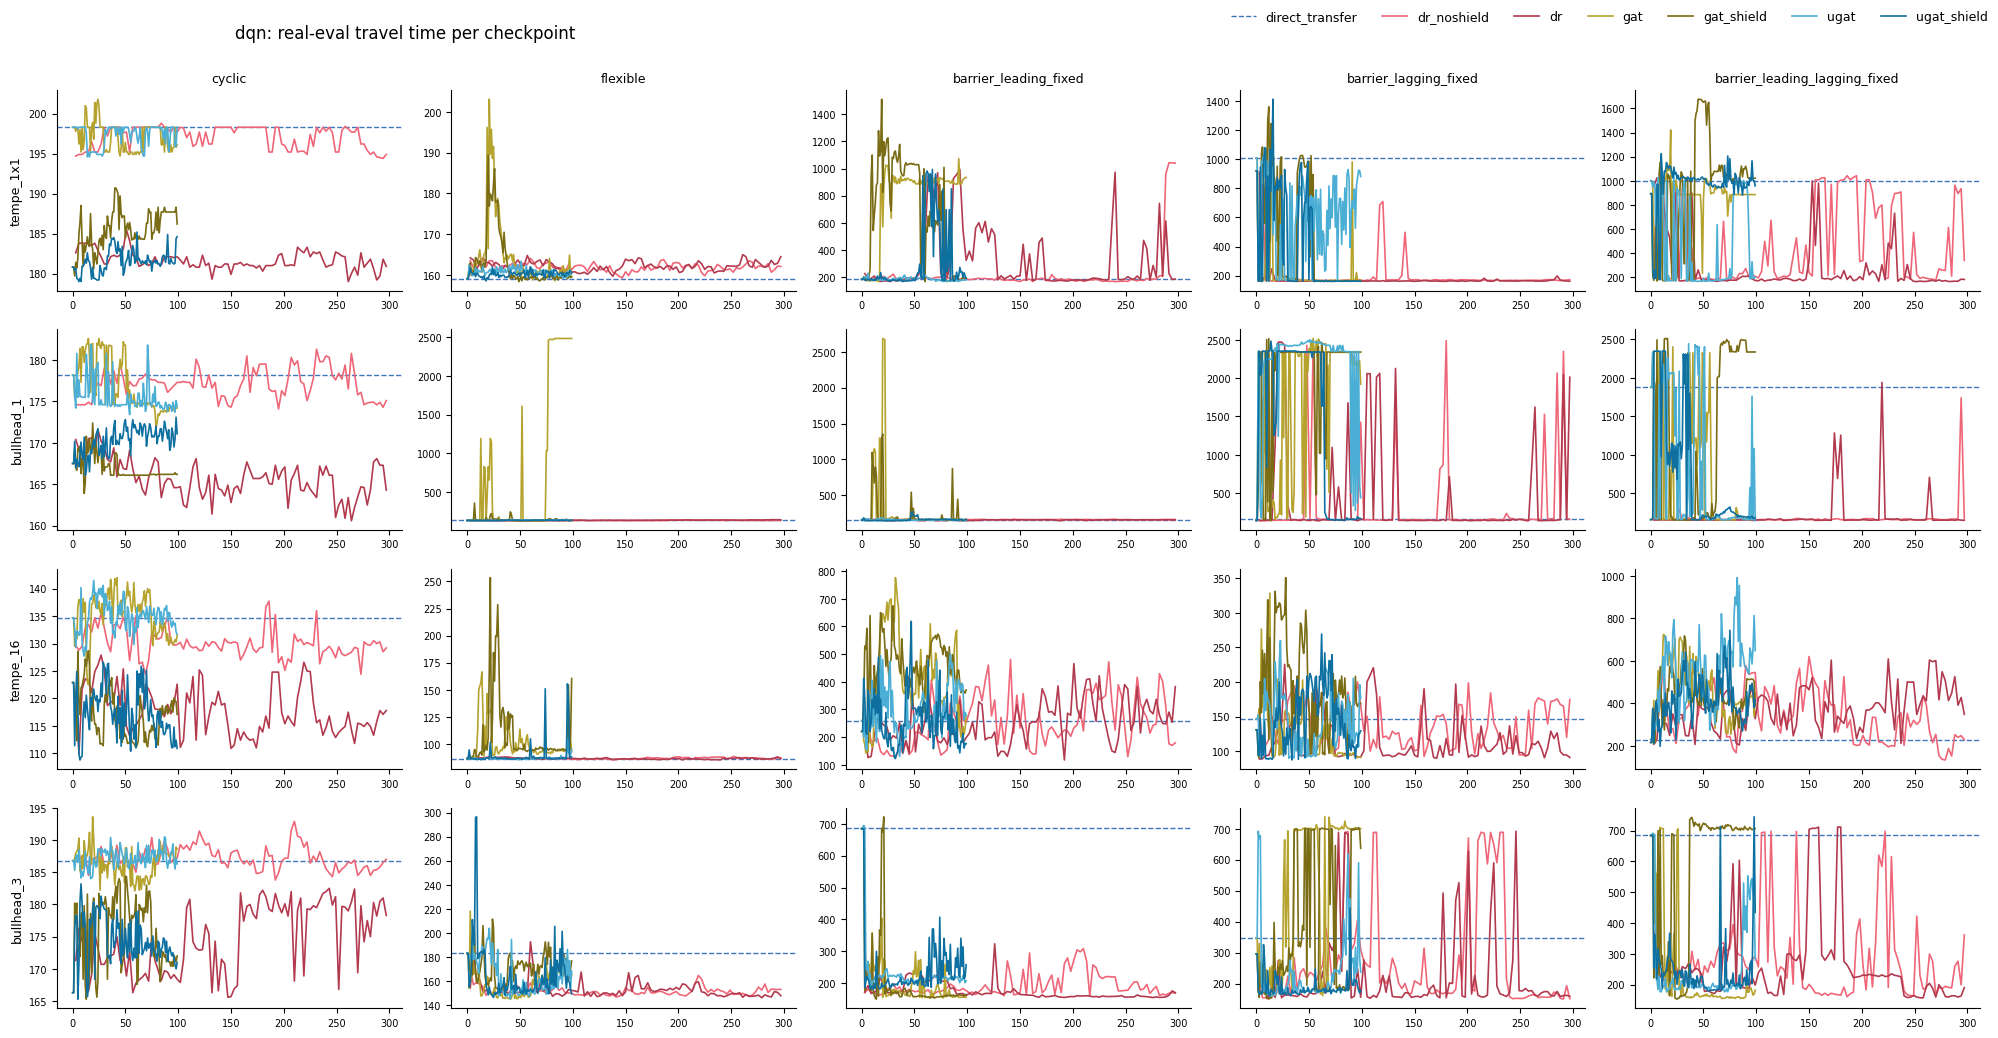

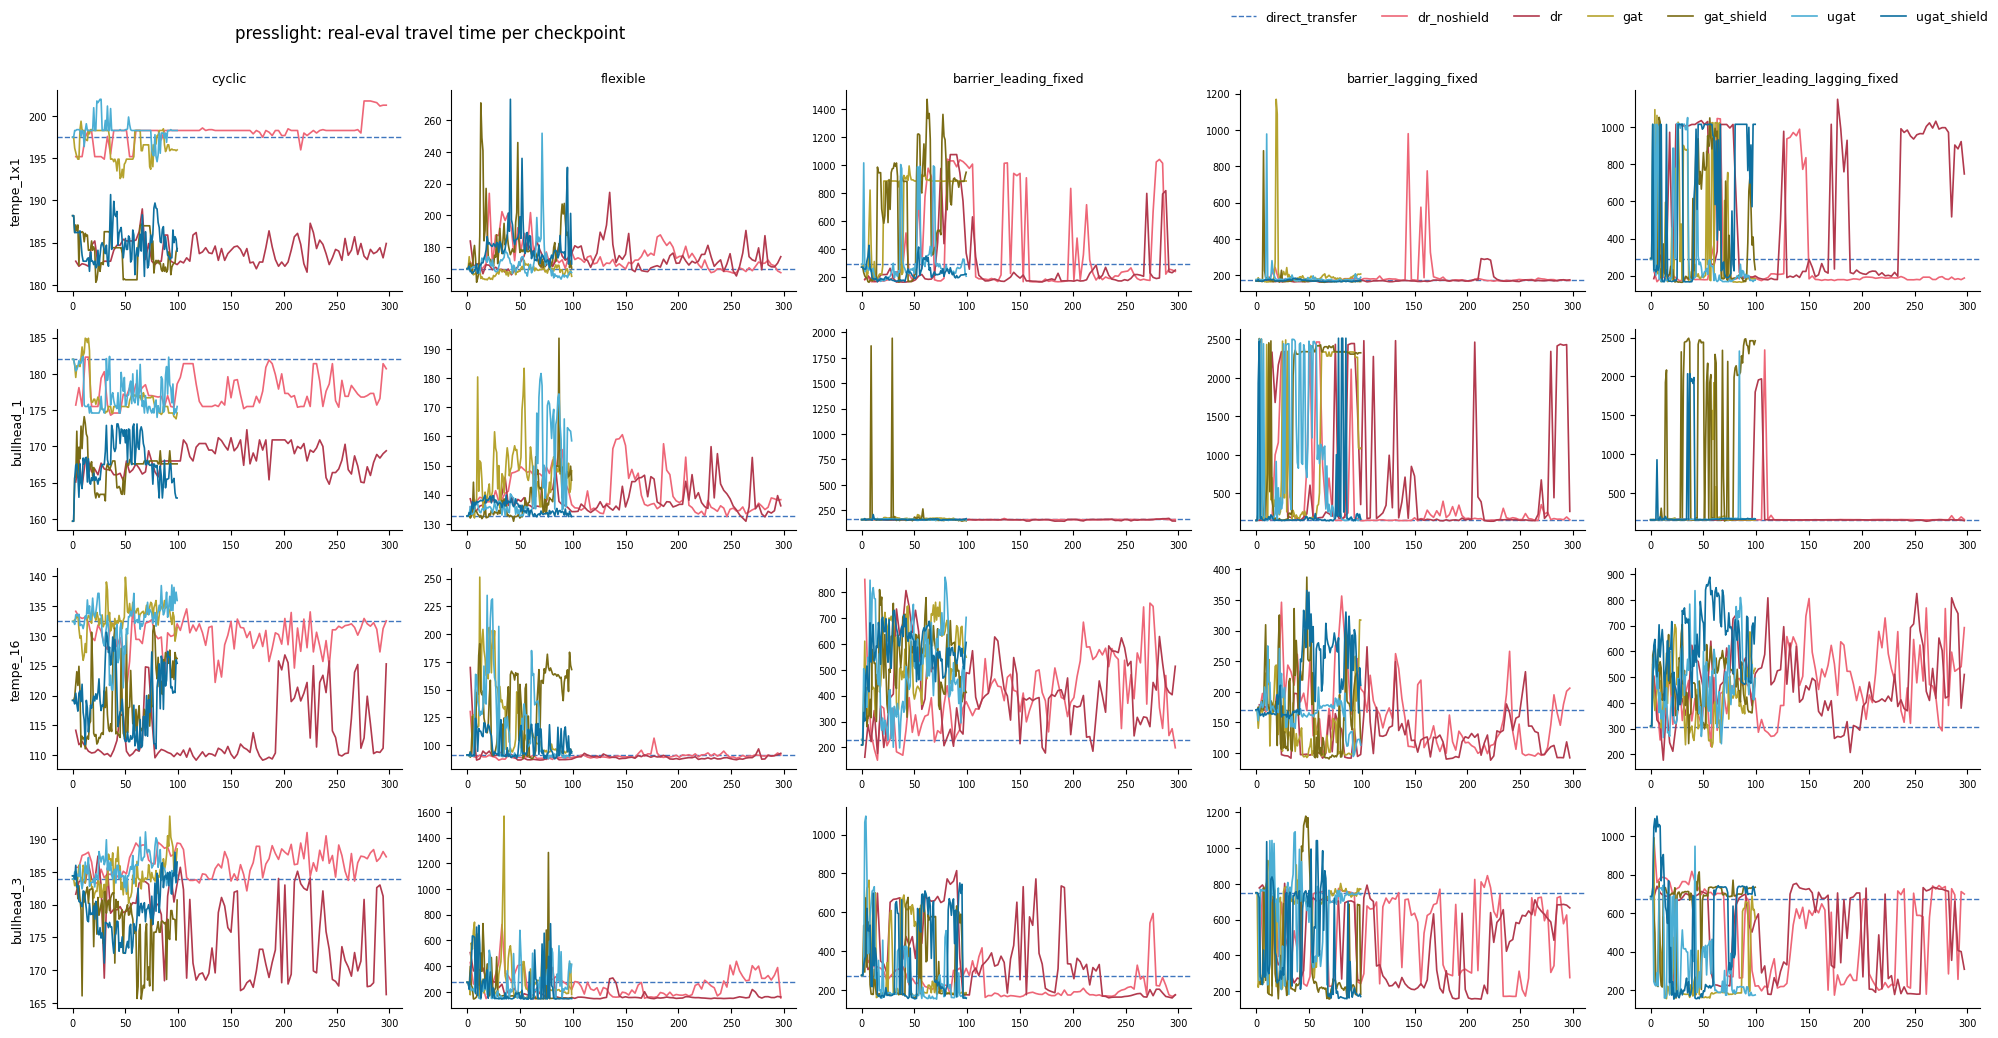

In [15]:
# Real-eval travel-time curves per checkpoint. direct_transfer (single zero-shot row)
# is drawn as a dashed reference line.
TRACE_NETWORKS = PT_NETWORKS
TRACE_SETTINGS = PT_SETTING_ORDER
TRACE_METHODS = PT_METHOD_ORDER


def real_trace(agent, network, method, setting):
    for log_path in reversed(pt_candidate_dtls(agent, network, method, setting)):
        rows = real_rows(read_dtl(log_path))
        if len(rows) >= 2:
            return rows.sort_values('episode')
    return None


for agent in AGENTS:
    fig, axes = plt.subplots(len(TRACE_NETWORKS), len(TRACE_SETTINGS),
                             figsize=(4 * len(TRACE_SETTINGS), 2.6 * len(TRACE_NETWORKS)), squeeze=False)
    for r, network in enumerate(TRACE_NETWORKS):
        for c, setting in enumerate(TRACE_SETTINGS):
            ax = axes[r, c]
            for method in TRACE_METHODS:
                if method in SINGLE_SHOT_METHODS:
                    dt = pt_results_df[(pt_results_df['agent'] == agent) & (pt_results_df['network'] == network)
                                    & (pt_results_df['setting'] == setting) & (pt_results_df['method'] == method)]
                    if len(dt):
                        ax.axhline(float(dt['travel_time'].iloc[0]), color=METHOD_COLORS[method],
                                   linestyle='--', linewidth=1.0, label=method)
                    continue
                rows = real_trace(agent, network, method, setting)
                if rows is None:
                    continue
                ax.plot(rows['episode'], rows['travel_time'], color=METHOD_COLORS[method],
                        linewidth=1.2, label=method)
            if r == 0:
                ax.set_title(setting, fontsize=9)
            if c == 0:
                ax.set_ylabel(network, fontsize=9)
            ax.tick_params(labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9, frameon=False, ncols=len(TRACE_METHODS))
    fig.suptitle(f'{agent}: real-eval travel time per checkpoint', x=0.12, ha='left')
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()